## Data Loading

This dataset contains daily observations of lettuce growth under different light conditions.
The variables include daily PAR (photosynthetically active radiation), plant weight, and daily growth.

The goal of this analysis is to explore how light conditions and plant size affect daily lettuce growth and to simulate harvest timing under different weather scenarios.

In [55]:
import pandas as pd

df = pd.read_csv("/content/Lettuce.csv")

df.head()

,sample_id,date,daily_PAR,weight_g,days_after_transplant,daily_growth
0,A,2025/9/22,10.0,101.00,15.0,3.20
1,A,2025/9/23,7.5,106.50,16.0,5.50
2,A,2025/9/24,8.0,110.90,17.0,4.40
3,A,2025/9/25,8.5,115.58,18.0,4.68
4,A,2025/9/26,8.5,120.28,19.0,4.70


## Data Exploration

Before building a model, we examine the structure and quality of the dataset.
This step helps us understand the data types, detect missing values, and verify that the variables are ready for analysis.


In [56]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   sample_id              45 non-null     object 
 1   date                   45 non-null     object 
 2   daily_PAR              45 non-null     float64
 3   weight_g               45 non-null     float64
 4   days_after_transplant  45 non-null     float64
 5   daily_growth           45 non-null     float64
dtypes: float64(4), object(2)
memory usage: 2.3+ KB


,0
sample_id,1
date,1
daily_PAR,1
weight_g,1
days_after_transplant,1
daily_growth,1


## Data Visualization

To better understand the relationships between variables, we visualize the data using scatter plots.
These plots help reveal how daily PAR and plant weight influence lettuce growth.

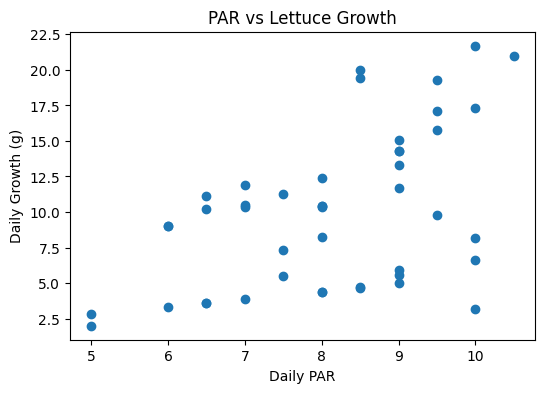

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.scatter(df["daily_PAR"], df["daily_growth"])

plt.xlabel("Daily PAR")
plt.ylabel("Daily Growth (g)")
plt.title("PAR vs Lettuce Growth")

plt.show()

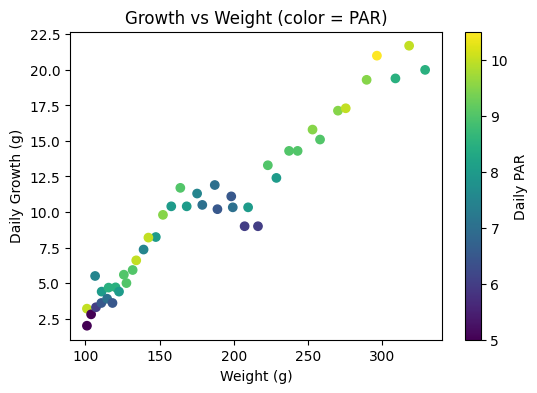

In [58]:
plt.figure(figsize=(6,4))

plt.scatter(
    df["weight_g"],
    df["daily_growth"],
    c=df["daily_PAR"],
    cmap="viridis"
)

plt.xlabel("Weight (g)")
plt.ylabel("Daily Growth (g)")
plt.title("Growth vs Weight (color = PAR)")

plt.colorbar(label="Daily PAR")

plt.show()

## Regression Model

To quantify the relationship between environmental conditions and plant growth,
we build a linear regression model using daily PAR and plant weight as predictors.

The model estimates how these variables contribute to daily lettuce growth.

In [59]:
from sklearn.linear_model import LinearRegression

df = df.dropna()

X = df[["daily_PAR","weight_g"]]
y = df["daily_growth"]

model = LinearRegression()
model.fit(X,y)

print("PAR coefficient:", model.coef_[0])
print("Weight coefficient:", model.coef_[1])
print("intercept:", model.intercept_)

PAR coefficient: 0.5356934247075498
Weight coefficient: 0.07396235200287472
intercept: -7.843026556496506


## Model Evaluation

To evaluate the performance of the regression model, we compare predicted daily growth with the actual observed values.

This helps assess how well the model explains lettuce growth patterns in the dataset.

In [60]:
# Predict daily growth
df["predicted_growth"] = model.predict(X)

df.head()

,sample_id,date,daily_PAR,weight_g,days_after_transplant,daily_growth,predicted_growth
0,A,2025/9/22,10.0,101.00,15.0,3.20,4.984105
1,A,2025/9/23,7.5,106.50,16.0,5.50,4.051665
2,A,2025/9/24,8.0,110.90,17.0,4.40,4.644946
3,A,2025/9/25,8.5,115.58,18.0,4.68,5.258936
4,A,2025/9/26,8.5,120.28,19.0,4.70,5.606559


In [61]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mse = mean_squared_error(y, df["predicted_growth"])
r2 = r2_score(y, df["predicted_growth"])

print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Squared Error: 1.332046205534425
R² Score: 0.954374092994636


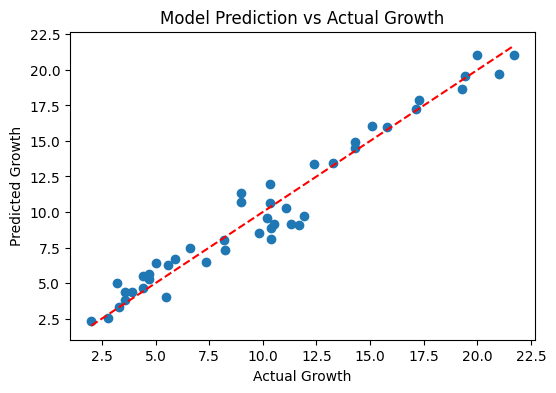

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.scatter(y, df["predicted_growth"])

plt.xlabel("Actual Growth")
plt.ylabel("Predicted Growth")

plt.title("Model Prediction vs Actual Growth")

plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')

plt.show()

The scatter plot compares predicted growth values with the actual observations.

If the model performs well, points should lie close to the diagonal line, indicating accurate predictions.

## Harvest Forecast Simulation

Using the regression model, we simulate lettuce growth under different weather conditions.
Starting from a given plant weight, we estimate daily growth and predict how many days it takes to reach harvest weight under different PAR scenarios.

In [65]:
def forecast_harvest(model, start_weight, target_weight, future_PAR_list):

    weight = start_weight
    day = 0

    for par in future_PAR_list:

        if weight >= target_weight:
            break

        X_pred = pd.DataFrame({
            "daily_PAR": [par],
            "weight_g": [weight]
        })

        growth = model.predict(X_pred)[0]

        weight += growth
        day += 1

        print(f"Day {day}: PAR={par}, Growth={growth:.2f}, Weight={weight:.2f}")

    if weight >= target_weight:
        print(f"Harvest in {day} days")
    else:
        print("Not yet harvested within forecast period")

In [66]:
forecast_harvest(model, 200, 250, [9,9,9,9,9,9,9])
forecast_harvest(model, 200, 250, [5,6,9,9,9,9,9])
forecast_harvest(model, 200, 250, [5,5,6,5,6,5,6])

Day 1: PAR=9, Growth=11.77, Weight=211.77
Day 2: PAR=9, Growth=12.64, Weight=224.41
Day 3: PAR=9, Growth=13.58, Weight=237.99
Day 4: PAR=9, Growth=14.58, Weight=252.57
Harvest in 4 days
Day 1: PAR=5, Growth=9.63, Weight=209.63
Day 2: PAR=6, Growth=10.88, Weight=220.50
Day 3: PAR=9, Growth=13.29, Weight=233.79
Day 4: PAR=9, Growth=14.27, Weight=248.06
Day 5: PAR=9, Growth=15.33, Weight=263.39
Harvest in 5 days
Day 1: PAR=5, Growth=9.63, Weight=209.63
Day 2: PAR=5, Growth=10.34, Weight=219.97
Day 3: PAR=6, Growth=11.64, Weight=231.61
Day 4: PAR=5, Growth=11.97, Weight=243.57
Day 5: PAR=6, Growth=13.39, Weight=256.96
Harvest in 5 days
